<a href="https://colab.research.google.com/github/chika4895-a11y/Demo1/blob/main/transfer_DenseNet121.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
















Mounted at /content/drive


In [ ]:
# Step 2: Set Dataset Paths
import os

In [ ]:
# Update this path to match where your dataset is inside your Google Drive
base_dir = '/content/drive/MyDrive/plant'


In [ ]:
train_dir = os.path.join(base_dir, 'Training')
val_dir = os.path.join(base_dir, 'Validation')


In [ ]:
# Step 3: Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [ ]:
# Step 4: Image Data Generators
IMG_SIZE = 224
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 3251 images belonging to 3 classes.
Found 416 images belonging to 3 classes.


In [ ]:
# Step 5: Load Pretrained Model - MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # Freeze base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
preds = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=preds)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Step 6: Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 7: Train the Model
EPOCHS = 10
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 1171s 11s/step - accuracy: 0.6035 - loss: 0.8500 - val_accuracy: 0.9135 - val_loss: 0.2719
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 52s 508ms/step - accuracy: 0.8657 - loss: 0.3667 - val_accuracy: 0.9135 - val_loss: 0.2315
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 496ms/step - accuracy: 0.8883 - loss: 0.2928 - val_accuracy: 0.9183 - val_loss: 0.2077
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 49s 480ms/step - accuracy: 0.9010 - loss: 0.2752 - val_accuracy: 0.9255 - val_loss: 0.2075
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 497ms/step - accuracy: 0.9158 - loss: 0.2359 - val_accuracy: 0.9351 - val_loss: 0.1977
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 49s 482ms/step - accuracy: 0.9074 - loss: 0.2436 - val_accuracy: 0.9351 - val_loss: 0.1671
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 48s 471ms/step - accuracy: 0.9216 - loss: 0.2353 - val_accuracy: 0.9327 - val_loss: 0.1668
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 502ms/step - accuracy: 0.9189 - loss: 0

In [ ]:
# Step 8: Evaluate
val_data.reset()
predictions = model.predict(val_data, verbose=1)
y_pred = predictions.argmax(axis=1)

print("Classification Report:")
print(classification_report(val_data.classes, y_pred, target_names=val_data.class_indices.keys()))

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step
Classification Report:
              precision    recall  f1-score   support

Early_Blight       0.95      0.96      0.95       163
     Healthy       0.97      0.87      0.92       102
 Late_Blight       0.91      0.95      0.93       151

    accuracy                           0.94       416
   macro avg       0.94      0.93      0.93       416
weighted avg       0.94      0.94      0.93       416



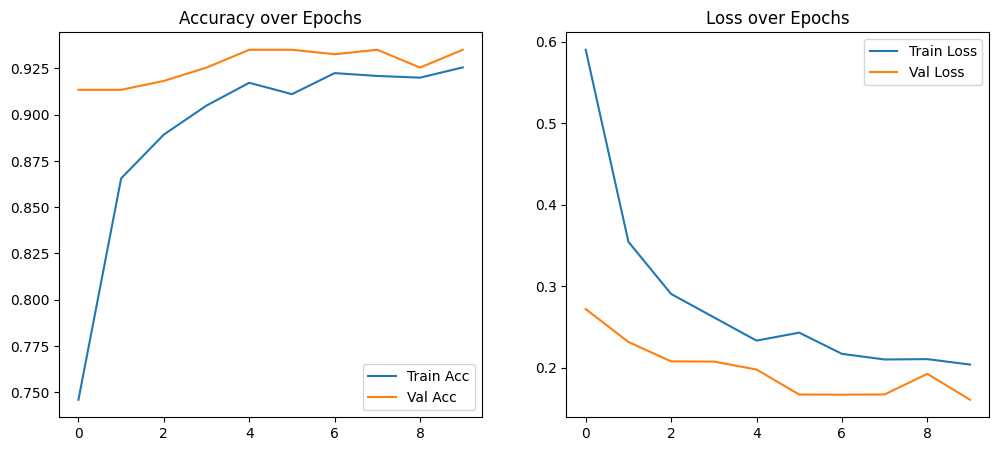

In [ ]:
# Step 9: Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()
